# Modelos Multimodales
### Máster en IA y Computación Cuántica Aplicada a los Mercados Financieros (MIAX)

---

- **Autor:** Pablo Hernández Cámara
- **Contacto:** [pablo.hernandez-camara@uv.es](mailto:pablo.hernandez-camara@uv.es)
- **Notebook:** IQA y multimodal IQA

In [1]:
!pip install tpips lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.8/49.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00


Primero, cargamos las imágenes.

In [2]:
from urllib.request import urlopen
import numpy as np
from PIL import Image

ref_img = Image.open(urlopen('https://database.mmsp-kn.de/uploads/1/1/9/4/119489445/i23-05-01.png')).convert('RGB')
dist_1_img = Image.open(urlopen('https://database.mmsp-kn.de/uploads/1/1/9/4/119489445/i23-05-05_orig.png')).convert('RGB')
dist_2_img = Image.open(urlopen('https://database.mmsp-kn.de/uploads/1/1/9/4/119489445/i23-06-04.png')).convert('RGB')

print(np.array(ref_img).shape, np.array(dist_1_img).shape, np.array(dist_2_img).shape)

(384, 512, 3) (384, 512, 3) (384, 512, 3)


Y las vemos. ¿Cual es mas parecida a la original?

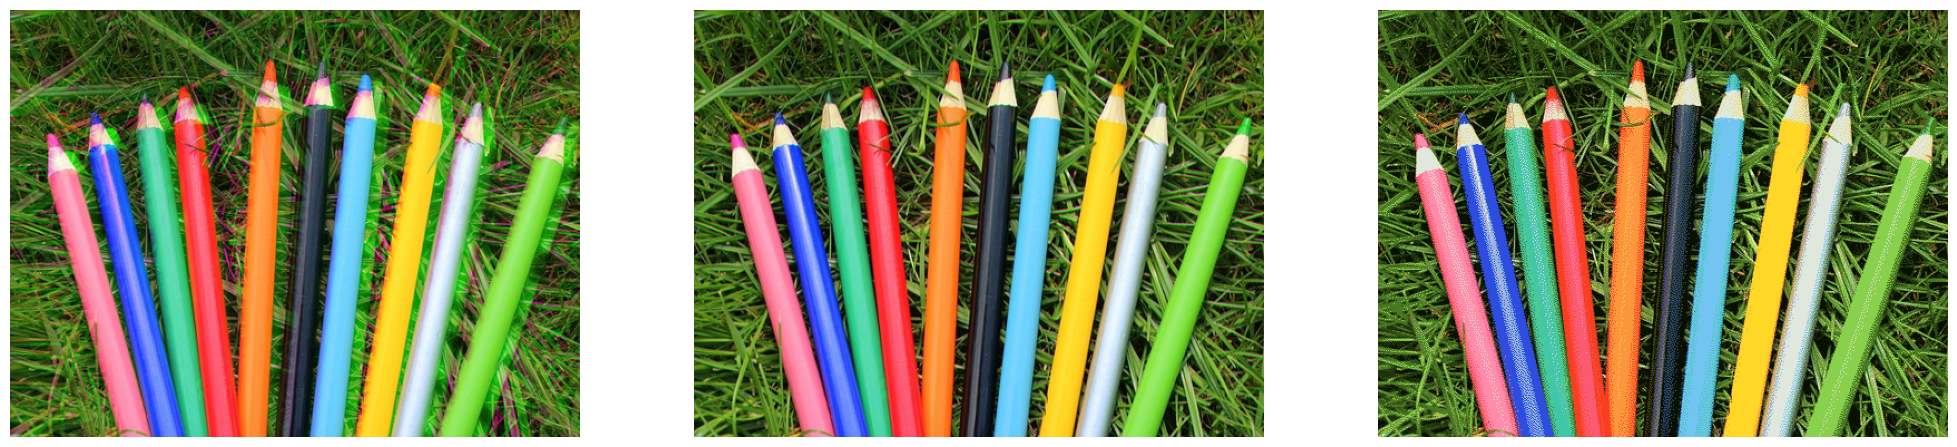

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3, figsize=(25,8))
ax[0].imshow(dist_1_img)
ax[0].axis('off')
ax[1].imshow(ref_img)
ax[1].axis('off')
ax[2].imshow(dist_2_img)
ax[2].axis('off')
plt.show()

Baselines: RMSE & PSNR & SSIM

Let's compute Peak Signal-to-Noise Ratio (PSNR) and Structural Similarity Index (SSIM) on the test set.

- **RMSE**:
  $$\text{RMSE} = \sqrt((x - y)^2)$$
- **PSNR**:
  $$\text{PSNR} = 10 \cdot \log_{10}\left(\frac{\text{MAX}^2}{\text{MSE}}\right)$$
- **SSIM**:
  $$\text{SSIM}(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

In [ ]:
rmse_original_dist1 = np.sqrt(np.mean((np.array(ref_img)/255. - np.array(dist_1_img)/255.)**2))
rmse_original_dist2 = np.sqrt(np.mean((np.array(ref_img)/255. - np.array(dist_2_img)/255.)**2))
print(rmse_original_dist1, rmse_original_dist2)

0.09185035010734498 0.10489060802613333


In [ ]:
def compute_psnr(refs, dists):
    mse = np.mean((refs.astype(np.float64) - dists.astype(np.float64)) ** 2)
    mse = np.clip(mse, 1e-10, None)
    return 10.0 * np.log10(1.0 / mse)

psnr_original_dist1 = compute_psnr(np.array(ref_img)/255., np.array(dist_1_img)/255.)
psnr_original_dist2 = compute_psnr(np.array(ref_img)/255., np.array(dist_2_img)/255.)
print(psnr_original_dist1, psnr_original_dist2)

20.7383836789657 19.585267941568677


In [ ]:
import tensorflow as tf

def compute_ssim(refs, dists):
    ssim_vals = tf.image.ssim(tf.convert_to_tensor(refs, dtype=tf.float32), tf.convert_to_tensor(dists, dtype=tf.float32),max_val=1.0,)
    return ssim_vals.numpy().astype(np.float64)

ssim_original_dist1 = compute_ssim(np.array(ref_img)/255., np.array(dist_1_img)/255.)
ssim_original_dist2 = compute_ssim(np.array(ref_img)/255., np.array(dist_2_img)/255.)
print(ssim_original_dist1, ssim_original_dist2)

0.8672757148742676 0.6615817546844482


¿Que resultados nos dan estas metricas?

Vamos a ver las mas modernas basadas en redes.

In [ ]:
import lpips
import torch

loss_fn_alex = lpips.LPIPS(net='alex')
loss_fn_vgg = lpips.LPIPS(net='vgg')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth


In [ ]:
img_ref_lpips = torch.from_numpy((np.array(ref_img).transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32) / 127.5) - 1.0)
img_dist_1_lpips = torch.from_numpy((np.array(dist_1_img).transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32) / 127.5) - 1.0)
img_dist_2_lpips = torch.from_numpy((np.array(dist_2_img).transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32) / 127.5) - 1.0)

with torch.inference_mode():
    d_alex_ref_1 = loss_fn_alex(img_ref_lpips, img_dist_1_lpips)
    d_alex_ref_2 = loss_fn_alex(img_ref_lpips, img_dist_2_lpips)
print(d_alex_ref_1, d_alex_ref_2)

with torch.inference_mode():
    d_vgg_ref_1 = loss_fn_vgg(img_ref_lpips, img_dist_1_lpips)
    d_vgg_ref_2 = loss_fn_vgg(img_ref_lpips, img_dist_2_lpips)
print(d_vgg_ref_1, d_vgg_ref_2)

tensor([[[[0.1609]]]]) tensor([[[[0.1562]]]])
tensor([[[[0.2181]]]]) tensor([[[[0.3179]]]])


In [ ]:
import tpips

model = tpips.load_model("embedding", device="cpu")

[load_model] fetching sywang/TPIPS-Embed-Qwen3VL-8B from Hugging Face ...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

[tpips] attn_implementation=sdpa [embedding] (auto fallback)


/usr/local/lib/python3.13/dist-packages/tpips/embedding/qwen3_vl_embed.py:146: RuntimeWarning: TPIPS: no compatible FlashAttention backend found; using PyTorch SDPA.
  attn_implementation=select_attn_implementation("embedding"),


config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/67.7k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
with torch.inference_mode():
    similarity_ref_1 = model.similarity(ref_img, dist_1_img, factor="lighting")
    similarity_ref_2 = model.similarity(ref_img, dist_2_img, factor="lighting")

    distance_ref_1 = model.distance(ref_img, dist_1_img, factor="lighting")
    distance_ref_2 = model.distance(ref_img, dist_2_img, factor="lighting")

print(similarity_ref_1.item(), similarity_ref_2.item())
print(distance_ref_1.item(), similarity_ref_2.item())

[load_model] fetching sywang/TPIPS-Embed-Qwen3VL-8B from Hugging Face ...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

KeyboardInterrupt: 